# 기계학습의 Underfitting, Overfitting 알아보기
---
* 이 글은 사이킷런 공식 홈페이지의 [Underfitting vs. Overfitting](https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html) 문서를 재구성해서 작성했습니다.  

기계학습 모델을 만들 때, 흔히 발생하는 문제 중 하나는 과(대)적합(Overfitting)과 과소적합(Underfitting)입니다. 전자의 경우 학습 데이터(Train set)의 사소한 특징까지도 학습하기 때문에 모델이 실제 데이터(Ground truth)와 동떨어진 예측을 하는 문제이며, 후자의 경우에는 실제 데이터를 표현하기에 모델이 턱없이 단순한 경우 발생하는 문제입니다.  
</p></br></br>

이번에는 파이썬(Python)의 대표적인 기계학습 라이브러리인 사이킷런(scikit-learn)을 활용해서 과적합과 과소적합의 사례 및 모델과 실제 데이터 사이의 괴리를 알아보도록 하겠습니다.  
</p></br></br>

이번에는 $\cos (1.5 \pi x)$ 함수 데이터를 생성한 다음, 단순 선형 회귀(Simple Linear Regression) 모델 및 다항 회귀(Polynimial Regression) 모델을 활용해 학습하도록 하겠습니다.
</p></br></br>

## 데이터 준비하기
---

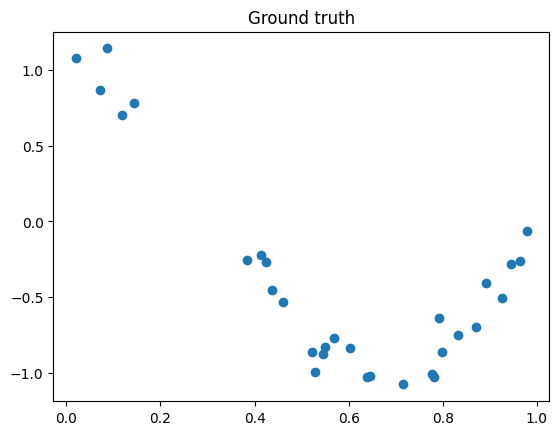

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score


def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)
n_samples = 30

# X: 30개의 랜덤 값
X = np.sort(np.random.rand(n_samples))

# y: true_fun() 반환값에 노이즈가 추가된 값
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.scatter(X, y)
plt.title('Ground truth')
plt.show()

</p></br></br>

## 과적합, 과소적합 사례 시각화하기
---
이제, 위 데이터를 이용해서 과적합 및 과소적합 사례를 시각화해 보도록 하겠습니다. 1차, 4차, 15차 함수로 위 데이터를 표현하면 각각 과소적합, 올바른 함수, 과적합의 예시를 확인할 수 있습니다.  
</p></br></br>


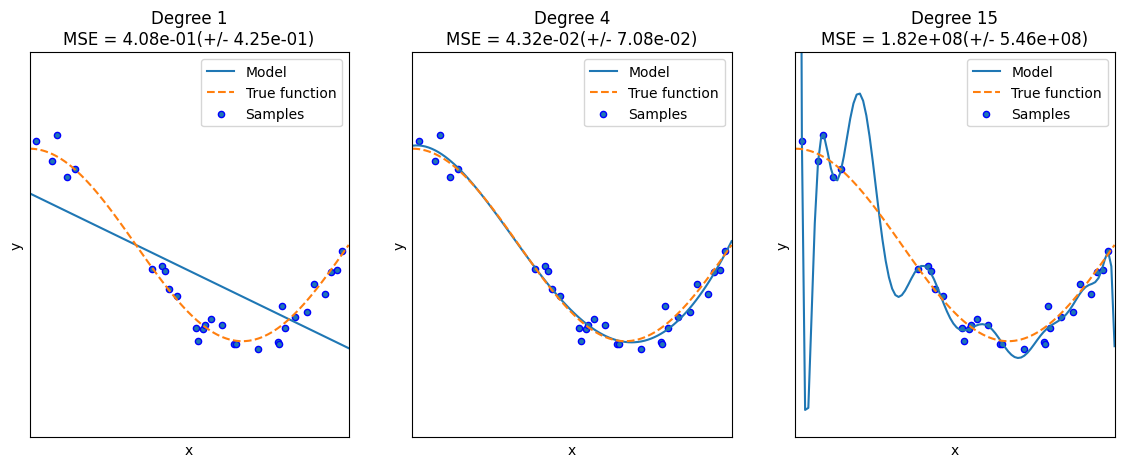

In [2]:
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

# n차 함수 작성하기
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    # 다항 회귀
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline(
        [
            ("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)
        ]
    )
    pipeline.fit(X.reshape(-1, 1), y)

    # 교차 검증
    scores = cross_val_score(
        pipeline, X.reshape(-1,1), y,scoring="neg_mean_squared_error", cv=10
    )

    # X_test를 이용한 회귀 후, Ground truth와 비교
    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), '--', label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title(f"Degree {degrees[i]}\nMSE = {-scores.mean():.2e}(+/- {scores.std():.2e})")

plt.show()

</p></br></br>

위 그래프를 보면, 1차 함수일 때는 실제 데이터에 비해 너무 단순한 그래프가 그려지는(과소적합) 것을 볼 수 있습니다. 4차 함수일 때는 True function과 거의 유사한 그래프가 그려지며, 15차 함수일 때는 각 샘플 하나하나에 지나치게 민감한(과적합) 그래프가 그려지게 됩니다. 이 때문에, 과적합 및 과소적합이 일어나면 실제 예측 성능이 눈에 띄게 떨어지게 되지요.  